# Frequentist vs Bayesian Estimates Comparison

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
with open("../../data/processed/nhanes_ground_truth.json") as f:
    freq_data = json.load(f)

with open("../../data/processed/pymc_ground_truth_joint.json") as f:
    bayes_data = json.load(f)

print(f"Frequentist groups: {len(freq_data['distributions'])}")
print(f"Bayesian groups: {len(bayes_data['distributions'])}")

Frequentist groups: 157
Bayesian groups: 157


In [2]:
# Build comparison dataframe
rows = []
for key in freq_data['distributions']:
    if key not in bayes_data['distributions']:
        continue
    
    f = freq_data['distributions'][key]
    b = bayes_data['distributions'][key]
    
    rows.append({
        'key': key,
        'n': f['n'],
        'height_mu_freq': f['height_mean'],
        'height_mu_bayes': b['height']['mu'],
        'height_sigma_freq': f['height_std'],
        'height_sigma_bayes': b['height']['sigma'],
        'weight_mu_freq': f['weight_mean'],
        'weight_mu_bayes': b['weight']['mu'],
        'weight_sigma_freq': f['weight_std'],
        'weight_sigma_bayes': b['weight']['sigma'],
    })

df = pd.DataFrame(rows)
print(f"Comparison pairs: {len(df)}")
df.head()

Comparison pairs: 157


,key,n,height_mu_freq,height_mu_bayes,height_sigma_freq,height_sigma_bayes,weight_mu_freq,weight_mu_bayes,weight_sigma_freq,weight_sigma_bayes
0,Overall,6235,166.97,166.97,10.03,10.03,82.87,82.87,22.45,22.45
1,RIDAGEYR=34-48,1230,167.95,167.96,9.90,9.91,86.09,86.08,24.48,24.50
2,RIDAGEYR=62-70,1296,166.32,166.32,9.74,9.75,82.74,82.72,20.28,20.30
3,RIDAGEYR=18-33,1289,168.81,168.80,9.92,9.93,80.74,80.73,23.74,23.74
4,RIDAGEYR=49-61,1305,167.03,167.04,10.05,10.07,85.59,85.56,23.33,23.35


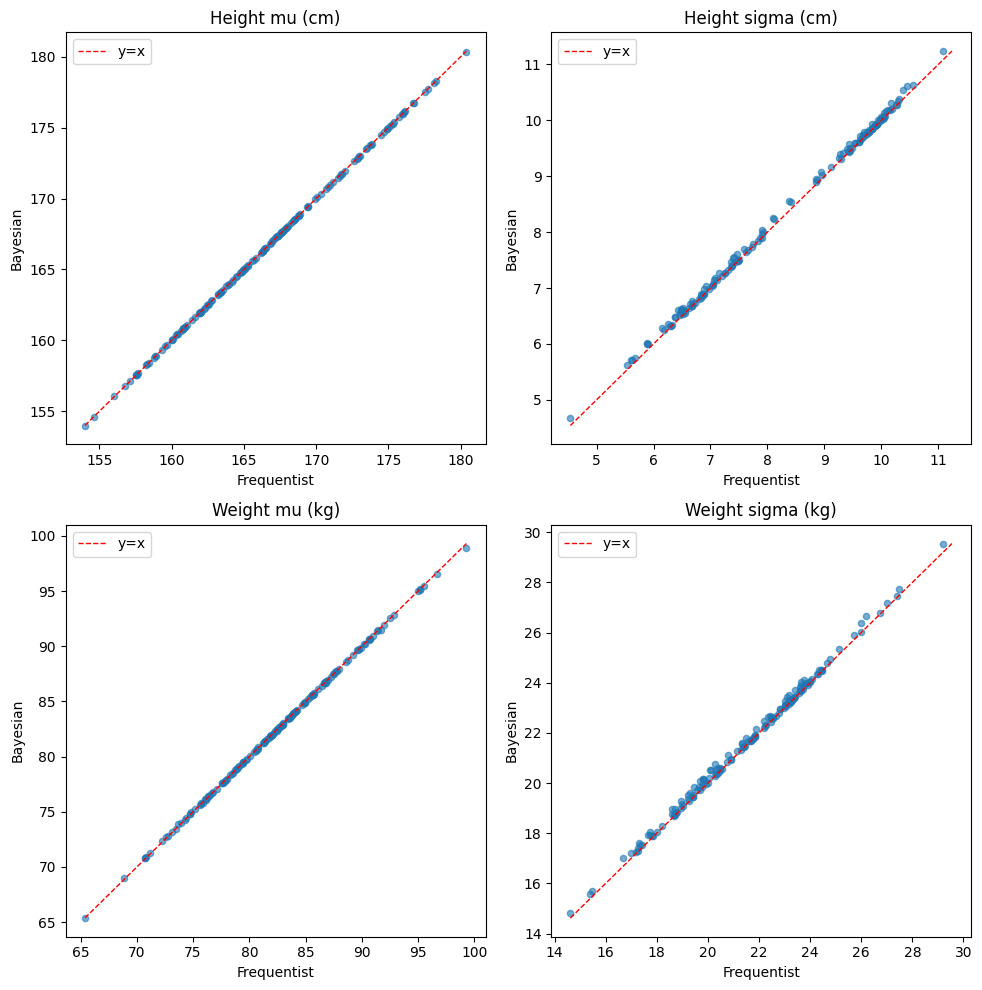

In [3]:
# Scatter plots: Frequentist vs Bayesian
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

plots = [
    ('height_mu_freq', 'height_mu_bayes', 'Height mu (cm)'),
    ('height_sigma_freq', 'height_sigma_bayes', 'Height sigma (cm)'),
    ('weight_mu_freq', 'weight_mu_bayes', 'Weight mu (kg)'),
    ('weight_sigma_freq', 'weight_sigma_bayes', 'Weight sigma (kg)'),
]

for ax, (x_col, y_col, title) in zip(axes.flat, plots):
    ax.scatter(df[x_col], df[y_col], alpha=0.6, s=20)
    
    # y=x line
    lims = [min(df[x_col].min(), df[y_col].min()), 
            max(df[x_col].max(), df[y_col].max())]
    ax.plot(lims, lims, 'r--', lw=1, label='y=x')
    
    ax.set_xlabel('Frequentist')
    ax.set_ylabel('Bayesian')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

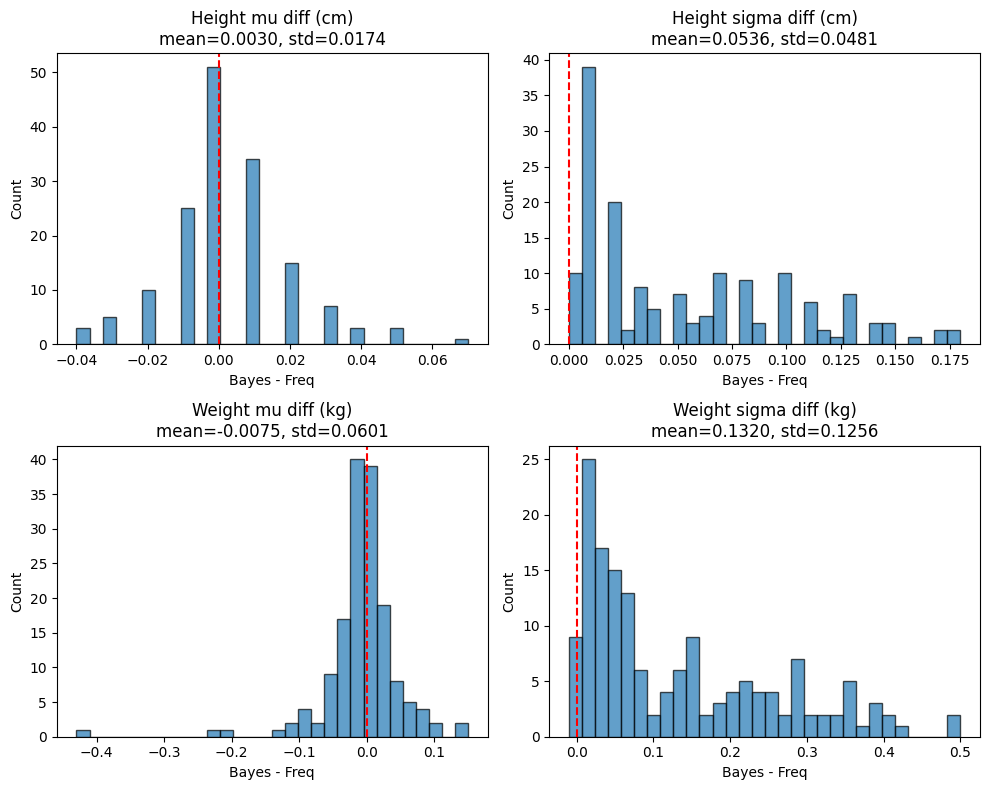

In [4]:
# Difference histograms
df['height_mu_diff'] = df['height_mu_bayes'] - df['height_mu_freq']
df['height_sigma_diff'] = df['height_sigma_bayes'] - df['height_sigma_freq']
df['weight_mu_diff'] = df['weight_mu_bayes'] - df['weight_mu_freq']
df['weight_sigma_diff'] = df['weight_sigma_bayes'] - df['weight_sigma_freq']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

diffs = [
    ('height_mu_diff', 'Height mu diff (cm)'),
    ('height_sigma_diff', 'Height sigma diff (cm)'),
    ('weight_mu_diff', 'Weight mu diff (kg)'),
    ('weight_sigma_diff', 'Weight sigma diff (kg)'),
]

for ax, (col, title) in zip(axes.flat, diffs):
    ax.hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_xlabel('Bayes - Freq')
    ax.set_ylabel('Count')
    ax.set_title(f'{title}\nmean={df[col].mean():.4f}, std={df[col].std():.4f}')

plt.tight_layout()
plt.show()

In [5]:
# Summary statistics
print("Difference Summary (Bayes - Freq):")
print("=" * 50)
for col in ['height_mu_diff', 'height_sigma_diff', 'weight_mu_diff', 'weight_sigma_diff']:
    print(f"{col:20s}: mean={df[col].mean():+.4f}, max|diff|={df[col].abs().max():.4f}")

Difference Summary (Bayes - Freq):
height_mu_diff      : mean=+0.0030, max|diff|=0.0700
height_sigma_diff   : mean=+0.0536, max|diff|=0.1800
weight_mu_diff      : mean=-0.0075, max|diff|=0.4300
weight_sigma_diff   : mean=+0.1320, max|diff|=0.5000
